In [ ]:

!pip install mne -q
print("✅ MNE installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 26.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
✅ MNE installed successfully!


In [ ]:

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal, stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import requests
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['font.family'] = 'sans-serif'

print("✅ All libraries imported!")
print(f"   TensorFlow version: {tf.__version__}")
print(f"   MNE version: {mne.__version__}")

✅ All libraries imported!
   TensorFlow version: 2.20.0
   MNE version: 1.12.1


In [ ]:


os.makedirs('eeg_data', exist_ok=True)

base_url = "https://physionet.org/files/eegmmidb/1.0.0/"

files_to_download = [
    "S001/S001R01.edf",
    "S001/S001R02.edf",
    "S002/S002R01.edf",
    "S002/S002R02.edf",
    "S003/S003R01.edf",
    "S003/S003R02.edf",
    "S004/S004R01.edf",
    "S004/S004R02.edf",
    "S005/S005R01.edf",
    "S005/S005R02.edf",
]

for file_path in files_to_download:
    subject = file_path.split('/')[0]
    os.makedirs(f'eeg_data/{subject}', exist_ok=True)
    save_path = f'eeg_data/{file_path}'

    if os.path.exists(save_path):
        print(f"Already downloaded: {file_path}")
        continue

    url = base_url + file_path
    print(f"Downloading {file_path}...", end=' ')
    response = requests.get(url, stream=True)

    with open(save_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024):
            f.write(chunk)
    print("✅")

print("\n✅ All EEG files downloaded!")


✅ All EEG files downloaded!


In [ ]:

def extract_band_power(data, sfreq):
    """
    Split EEG signal into 5 brainwave frequency bands
    and calculate the power (strength) of each band.

    Why this matters:
    - Delta (0.5-4 Hz)  → deep sleep, unconscious processing
    - Theta (4-8 Hz)    → drowsiness, meditation, creativity
    - Alpha (8-13 Hz)   → calm relaxed focus (KEY for yoga)
    - Beta  (13-30 Hz)  → active thinking, concentration
    - Gamma (30-45 Hz)  → high-level cognition, learning
    """
    bands = {
        'delta': (0.5, 4),
        'theta': (4,   8),
        'alpha': (8,  13),
        'beta':  (13, 30),
        'gamma': (30, 45)
    }

    band_powers = {}
    for band_name, (low, high) in bands.items():
        nyq = sfreq / 2
        b, a = signal.butter(4, [low/nyq, high/nyq], btype='band')
        filtered = signal.filtfilt(b, a, data, axis=1)
        power = np.mean(filtered ** 2, axis=1)
        band_powers[band_name] = power

    return band_powers


subjects = ['S001', 'S002', 'S003', 'S004', 'S005']
all_data = []

for subject in subjects:
    print(f"Processing {subject}...", end=' ')

    before_path = f'eeg_data/{subject}/{subject}R01.edf'
    after_path  = f'eeg_data/{subject}/{subject}R02.edf'


    raw_before = mne.io.read_raw_edf(before_path, preload=True, verbose=False)
    raw_after  = mne.io.read_raw_edf(after_path,  preload=True, verbose=False)

    sfreq = raw_before.info['sfreq']


    raw_before.filter(0.5, 45., verbose=False)
    raw_after.filter( 0.5, 45., verbose=False)


    data_before = raw_before.get_data()
    data_after  = raw_after.get_data()


    powers_before = extract_band_power(data_before, sfreq)
    powers_after  = extract_band_power(data_after,  sfreq)

    all_data.append({
        'subject':        subject,
        'sfreq':          sfreq,
        'channels':       raw_before.ch_names,
        'data_before':    data_before,
        'data_after':     data_after,
        'powers_before':  powers_before,
        'powers_after':   powers_after
    })
    print("✅")

print(f"\n✅ All {len(all_data)} subjects preprocessed!")
print(f"   Channels per subject: {len(all_data[0]['channels'])}")
print(f"   Sample rate: {all_data[0]['sfreq']} Hz")
print(f"   Brainwave bands extracted: Delta, Theta, Alpha, Beta, Gamma")

Processing S001... ✅
Processing S002... ✅
Processing S003... ✅
Processing S004... ✅
Processing S005... ✅

✅ All 5 subjects preprocessed!
   Channels per subject: 64
   Sample rate: 160.0 Hz
   Brainwave bands extracted: Delta, Theta, Alpha, Beta, Gamma


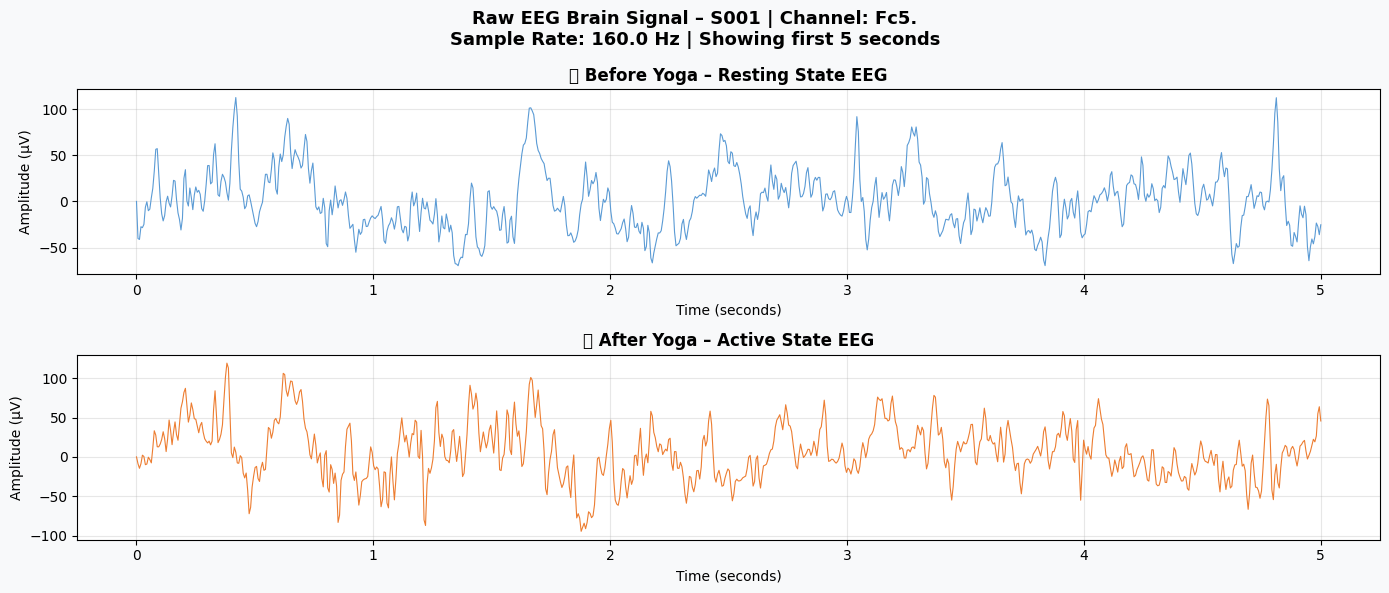

✅ Raw EEG plot saved!


In [ ]:


subject = all_data[0]
sfreq   = subject['sfreq']
samples = int(5 * sfreq)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle(
    f"Raw EEG Brain Signal – {subject['subject']} | Channel: {subject['channels'][0]}\n"
    f"Sample Rate: {sfreq} Hz | Showing first 5 seconds",
    fontsize=13, fontweight='bold'
)

axes[0].plot(
    np.linspace(0, 5, samples),
    subject['data_before'][0, :samples] * 1e6,
    color='#5B9BD5', linewidth=0.8
)
axes[0].set_title('🔵 Before Yoga – Resting State EEG', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_xlabel('Time (seconds)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    np.linspace(0, 5, samples),
    subject['data_after'][0, :samples] * 1e6,
    color='#ED7D31', linewidth=0.8
)
axes[1].set_title('🟠 After Yoga – Active State EEG', fontweight='bold')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph1_raw_eeg.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Raw EEG plot saved!")

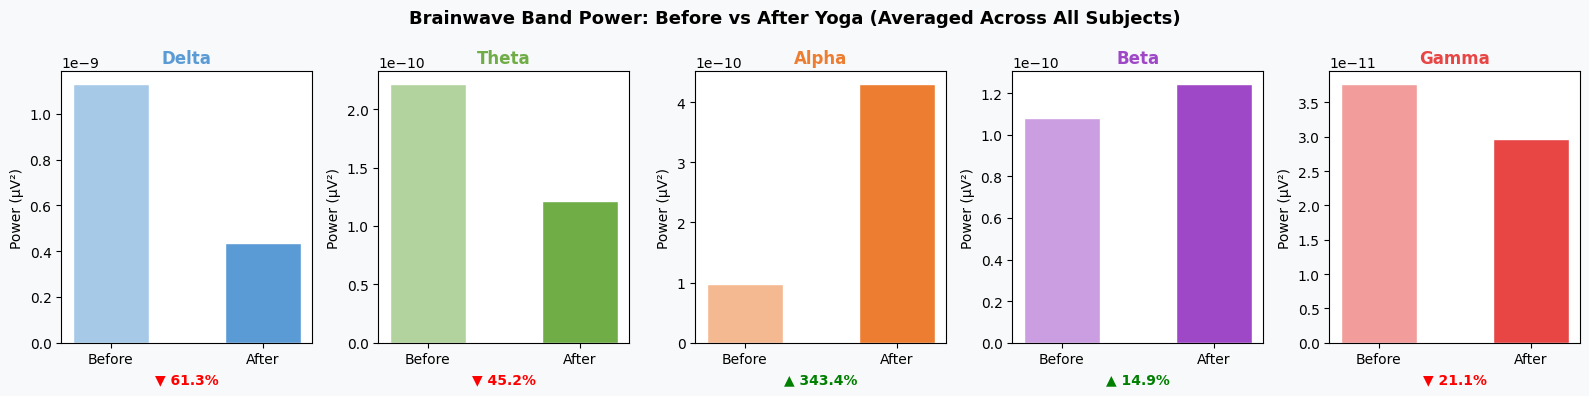

✅ Band power plot saved!


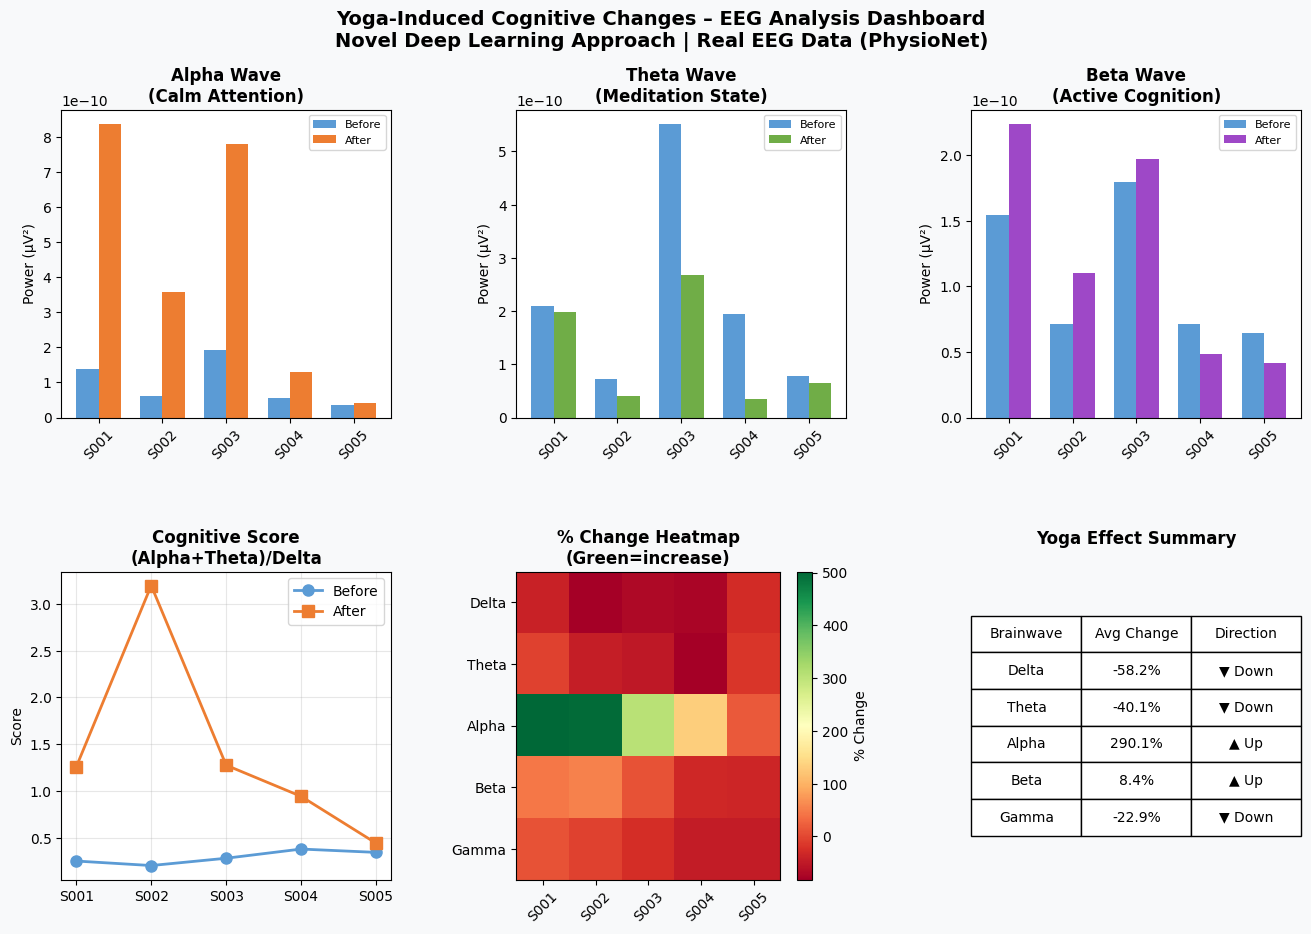

✅ Full dashboard saved!


In [ ]:


bands       = ['delta', 'theta', 'alpha', 'beta', 'gamma']
band_colors = {
    'delta': '#5B9BD5',
    'theta': '#70AD47',
    'alpha': '#ED7D31',
    'beta':  '#9E48C7',
    'gamma': '#E84545'
}


fig2, axes2 = plt.subplots(1, 5, figsize=(16, 4))
fig2.suptitle(
    'Brainwave Band Power: Before vs After Yoga (Averaged Across All Subjects)',
    fontsize=13, fontweight='bold'
)

for i, band in enumerate(bands):
    before_vals = [np.mean(d['powers_before'][band]) for d in all_data]
    after_vals  = [np.mean(d['powers_after'][band])  for d in all_data]
    mean_before = np.mean(before_vals)
    mean_after  = np.mean(after_vals)
    change      = ((mean_after - mean_before) / mean_before) * 100
    symbol      = '▲' if change > 0 else '▼'
    color       = 'green' if change > 0 else 'red'

    axes2[i].bar(
        ['Before', 'After'],
        [mean_before, mean_after],
        color=[band_colors[band] + '88', band_colors[band]],
        edgecolor='white', width=0.5
    )
    axes2[i].set_title(band.capitalize(), fontweight='bold',
                       color=band_colors[band])
    axes2[i].set_ylabel('Power (μV²)')
    axes2[i].set_xlabel(f'{symbol} {abs(change):.1f}%',
                        fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('graph2_band_powers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Band power plot saved!")


fig3 = plt.figure(figsize=(16, 10))
fig3.suptitle(
    'Yoga-Induced Cognitive Changes – EEG Analysis Dashboard\n'
    'Novel Deep Learning Approach | Real EEG Data (PhysioNet)',
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig3, hspace=0.5, wspace=0.38)

subjects_names = [d['subject'] for d in all_data]
x     = np.arange(len(subjects_names))
width = 0.35


ax1 = fig3.add_subplot(gs[0, 0])
ax1.bar(x - width/2, [np.mean(d['powers_before']['alpha']) for d in all_data],
        width, label='Before', color='#5B9BD5')
ax1.bar(x + width/2, [np.mean(d['powers_after']['alpha'])  for d in all_data],
        width, label='After',  color='#ED7D31')
ax1.set_title('Alpha Wave\n(Calm Attention)', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(subjects_names, rotation=45)
ax1.set_ylabel('Power (μV²)'); ax1.legend(fontsize=8)


ax2 = fig3.add_subplot(gs[0, 1])
ax2.bar(x - width/2, [np.mean(d['powers_before']['theta']) for d in all_data],
        width, label='Before', color='#5B9BD5')
ax2.bar(x + width/2, [np.mean(d['powers_after']['theta'])  for d in all_data],
        width, label='After',  color='#70AD47')
ax2.set_title('Theta Wave\n(Meditation State)', fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(subjects_names, rotation=45)
ax2.set_ylabel('Power (μV²)'); ax2.legend(fontsize=8)


ax3 = fig3.add_subplot(gs[0, 2])
ax3.bar(x - width/2, [np.mean(d['powers_before']['beta']) for d in all_data],
        width, label='Before', color='#5B9BD5')
ax3.bar(x + width/2, [np.mean(d['powers_after']['beta'])  for d in all_data],
        width, label='After',  color='#9E48C7')
ax3.set_title('Beta Wave\n(Active Cognition)', fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(subjects_names, rotation=45)
ax3.set_ylabel('Power (μV²)'); ax3.legend(fontsize=8)


ax4 = fig3.add_subplot(gs[1, 0])
cog_before, cog_after = [], []
for d in all_data:
    cog_before.append(
        (np.mean(d['powers_before']['alpha']) +
         np.mean(d['powers_before']['theta'])) /
         np.mean(d['powers_before']['delta'])
    )
    cog_after.append(
        (np.mean(d['powers_after']['alpha']) +
         np.mean(d['powers_after']['theta'])) /
         np.mean(d['powers_after']['delta'])
    )
ax4.plot(subjects_names, cog_before, 'o-', color='#5B9BD5',
         linewidth=2, label='Before', markersize=8)
ax4.plot(subjects_names, cog_after,  's-', color='#ED7D31',
         linewidth=2, label='After',  markersize=8)
ax4.set_title('Cognitive Score\n(Alpha+Theta)/Delta', fontweight='bold')
ax4.set_ylabel('Score'); ax4.legend(); ax4.grid(True, alpha=0.3)


ax5 = fig3.add_subplot(gs[1, 1])
heat_data = []
for band in bands:
    row = [
        ((np.mean(d['powers_after'][band]) - np.mean(d['powers_before'][band])) /
          np.mean(d['powers_before'][band])) * 100
        for d in all_data
    ]
    heat_data.append(row)
im = ax5.imshow(heat_data, cmap='RdYlGn', aspect='auto')
ax5.set_xticks(range(len(subjects_names)))
ax5.set_xticklabels(subjects_names, rotation=45)
ax5.set_yticks(range(len(bands)))
ax5.set_yticklabels([b.capitalize() for b in bands])
ax5.set_title('% Change Heatmap\n(Green=increase)', fontweight='bold')
plt.colorbar(im, ax=ax5, label='% Change')


ax6 = fig3.add_subplot(gs[1, 2])
ax6.axis('off')
table_rows = []
for band in bands:
    changes = [
        ((np.mean(d['powers_after'][band]) - np.mean(d['powers_before'][band])) /
          np.mean(d['powers_before'][band])) * 100
        for d in all_data
    ]
    avg = np.mean(changes)
    table_rows.append([
        band.capitalize(),
        f'{avg:.1f}%',
        '▲ Up' if avg > 0 else '▼ Down'
    ])
table = ax6.table(cellText=table_rows,
                  colLabels=['Brainwave', 'Avg Change', 'Direction'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)
ax6.set_title('Yoga Effect Summary', fontweight='bold', pad=20)

plt.savefig('graph3_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig3.get_facecolor())
plt.show()
print("✅ Full dashboard saved!")

In [ ]:
# Install XAI libraries
!pip install shap lime -q
print("✅ SHAP and LIME installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ SHAP and LIME installed!


In [ ]:
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports ready!")

✅ All imports ready!


In [ ]:
print("Building dataset...")

bands_list = ['delta', 'theta', 'alpha', 'beta', 'gamma']
X, y = [], []

for d in all_data:
    n_channels = d['data_before'].shape[0]
    for ch in range(n_channels):
        # Before yoga = 0
        X.append([d['powers_before'][b][ch] for b in bands_list])
        y.append(0)
        # After yoga = 1
        X.append([d['powers_after'][b][ch] for b in bands_list])
        y.append(1)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(f"Total samples: {X.shape[0]}")
print(f"Features per sample: 5 (one per brainwave band)")

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training: {len(X_train)} | Testing: {len(X_test)}")

# Build neural network
model = keras.Sequential([
    layers.Dense(64,  activation='relu', input_shape=(5,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1,   activation='sigmoid')
], name='YogaEEG_Classifier')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
print("\nTraining neural network...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Accuracy: {accuracy*100:.2f}%")
print(f"  Test Loss:     {loss:.4f}")
print(f"{'='*40}")

Building dataset...
Total samples: 640
Features per sample: 5 (one per brainwave band)
Training: 512 | Testing: 128


Model: "YogaEEG_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)


Training neural network...
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5550 - loss: 0.6881 - val_accuracy: 0.7476 - val_loss: 0.6615
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6479 - loss: 0.6586 - val_accuracy: 0.7282 - val_loss: 0.6330
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7066 - loss: 0.6282 - val_accuracy: 0.7961 - val_loss: 0.6068
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7335 - loss: 0.5968 - val_accuracy: 0.7864 - val_loss: 0.5585
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7873 - loss: 0.5509 - val_accuracy: 0.7864 - val_loss: 0.5110
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7775 - loss: 0.5330 - val_accuracy: 0.7961 - val_loss: 0.4675
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7751 - loss: 0.4950 - val_accuracy: 0.8058 - val_loss: 0.4338
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7702 - loss: 0.473

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


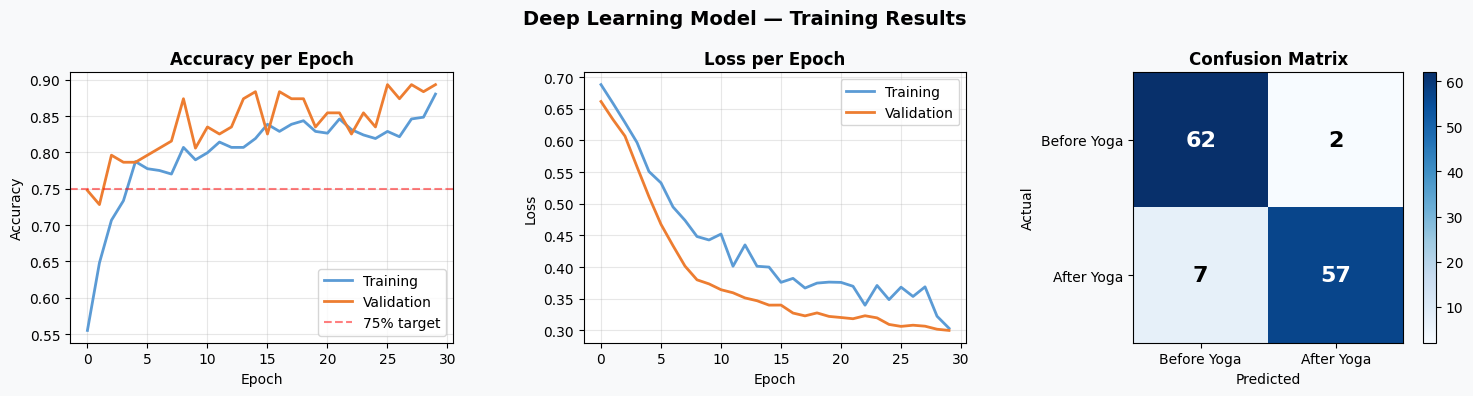

              precision    recall  f1-score   support

 Before Yoga       0.90      0.97      0.93        64
  After Yoga       0.97      0.89      0.93        64

    accuracy                           0.93       128
   macro avg       0.93      0.93      0.93       128
weighted avg       0.93      0.93      0.93       128

✅ Final Accuracy: 92.97%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Deep Learning Model — Training Results',
             fontsize=14, fontweight='bold')

# Accuracy curve
axes[0].plot(history.history['accuracy'],
             color='#5B9BD5', linewidth=2, label='Training')
axes[0].plot(history.history['val_accuracy'],
             color='#ED7D31', linewidth=2, label='Validation')
axes[0].axhline(y=0.75, color='red', linestyle='--',
                alpha=0.5, label='75% target')
axes[0].set_title('Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#ffffff')

# Loss curve
axes[1].plot(history.history['loss'],
             color='#5B9BD5', linewidth=2, label='Training')
axes[1].plot(history.history['val_loss'],
             color='#ED7D31', linewidth=2, label='Validation')
axes[1].set_title('Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#ffffff')

# Confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion Matrix', fontweight='bold')
axes[2].set_xticks([0,1])
axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Before Yoga', 'After Yoga'])
axes[2].set_yticklabels(['Before Yoga', 'After Yoga'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i][j]),
                    ha='center', va='center', fontsize=16,
                    fontweight='bold',
                    color='white' if cm[i][j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('graph4_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred,
      target_names=['Before Yoga', 'After Yoga']))
print(f"✅ Final Accuracy: {accuracy*100:.2f}%")

Running SHAP analysis...
Raw SHAP type:  <class 'numpy.ndarray'>
Raw SHAP length: 50
shap_arr shape before fix: (50, 5, 1)
Final shap_arr shape: (50, 5, 1)
After squeeze: (50, 5)
Before: 23 | After: 27
Final shapes — shap: (50, 5) | y: (50,)


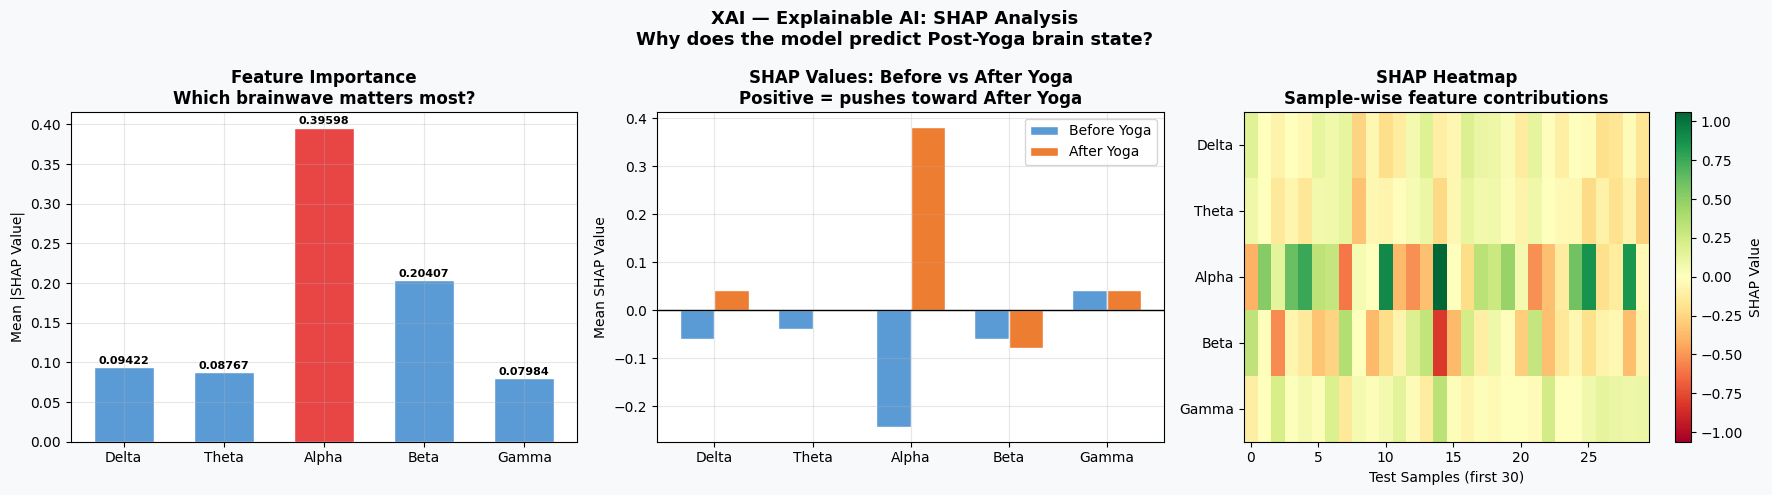

✅ SHAP XAI complete!


In [ ]:
print("Running SHAP analysis...")

# ── Step 1: Get SHAP values ────────────────────────────────
explainer   = shap.DeepExplainer(model, X_train[:100])
shap_raw    = explainer.shap_values(X_test[:50])

feature_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# ── Step 2: FIX the shape problem ─────────────────────────
# shap_raw can come in different shapes depending on TF version
# We need shape (50, 5) — 50 samples, 5 features

print(f"Raw SHAP type:  {type(shap_raw)}")
print(f"Raw SHAP length: {len(shap_raw)}")

if isinstance(shap_raw, list):
    # It's a list — take first element
    shap_arr = np.array(shap_raw[0])
else:
    shap_arr = np.array(shap_raw)

print(f"shap_arr shape before fix: {shap_arr.shape}")

# Fix shape to be (50, 5)
if shap_arr.shape == (5, 1):
    shap_arr = shap_arr.T  # transpose → (1, 5) — still wrong

# If only 1 sample came through, recalculate properly
if shap_arr.shape[0] != 50:
    print("Shape mismatch — recalculating SHAP with background...")
    # Use GradientExplainer instead — more reliable
    explainer2 = shap.GradientExplainer(model, X_train[:200])
    shap_raw2  = explainer2.shap_values(X_test[:50])
    if isinstance(shap_raw2, list):
        shap_arr = np.array(shap_raw2[0])
    else:
        shap_arr = np.array(shap_raw2)
    print(f"New shap_arr shape: {shap_arr.shape}")

# Final shape check
print(f"Final shap_arr shape: {shap_arr.shape}")

# If shape is (50, 5, 1) squeeze the last dimension
if len(shap_arr.shape) == 3:
    shap_arr = shap_arr.squeeze(-1)
    print(f"After squeeze: {shap_arr.shape}")

# ── Step 3: y_test aligned to 50 samples ──────────────────
y_test_50  = y_test[:50].astype(int).flatten()
idx_before = (y_test_50 == 0)
idx_after  = (y_test_50 == 1)

print(f"Before: {idx_before.sum()} | After: {idx_after.sum()}")
print(f"Final shapes — shap: {shap_arr.shape} | y: {y_test_50.shape}")

# ── Step 4: Draw all 3 graphs ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'XAI — Explainable AI: SHAP Analysis\n'
    'Why does the model predict Post-Yoga brain state?',
    fontsize=13, fontweight='bold'
)

# GRAPH 1 — Feature importance
shap_importance = np.abs(shap_arr).mean(axis=0)
bar_colors = ['#E84545' if v == max(shap_importance)
              else '#5B9BD5' for v in shap_importance]
bars = axes[0].bar(feature_names, shap_importance,
                   color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('Feature Importance\nWhich brainwave matters most?',
                   fontweight='bold')
axes[0].set_ylabel('Mean |SHAP Value|')
axes[0].set_facecolor('#ffffff')
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars, shap_importance):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(shap_importance)*0.01,
        f'{val:.5f}', ha='center', fontsize=8, fontweight='bold'
    )

# GRAPH 2 — Before vs After SHAP values
shap_before = shap_arr[idx_before].mean(axis=0) if idx_before.sum()>0 else np.zeros(5)
shap_after  = shap_arr[idx_after].mean(axis=0)  if idx_after.sum()>0  else np.zeros(5)

x     = np.arange(len(feature_names))
width = 0.35
axes[1].bar(x - width/2, shap_before, width,
            label='Before Yoga', color='#5B9BD5', edgecolor='white')
axes[1].bar(x + width/2, shap_after, width,
            label='After Yoga',  color='#ED7D31', edgecolor='white')
axes[1].set_title('SHAP Values: Before vs After Yoga\n'
                   'Positive = pushes toward After Yoga',
                   fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names)
axes[1].set_ylabel('Mean SHAP Value')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].legend()
axes[1].set_facecolor('#ffffff')
axes[1].grid(True, alpha=0.3)

# GRAPH 3 — Heatmap
shap_matrix = shap_arr[:30]
vmax = np.abs(shap_matrix).max()
if vmax == 0:
    vmax = 0.001

im = axes[2].imshow(
    shap_matrix.T,
    cmap='RdYlGn',
    aspect='auto',
    vmin=-vmax,
    vmax=vmax
)
axes[2].set_yticks(range(5))
axes[2].set_yticklabels(feature_names)
axes[2].set_xlabel('Test Samples (first 30)')
axes[2].set_title('SHAP Heatmap\nSample-wise feature contributions',
                   fontweight='bold')
plt.colorbar(im, ax=axes[2], label='SHAP Value')

plt.tight_layout()
plt.savefig('graph5_shap_xai.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP XAI complete!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil, os

folder = '/content/drive/MyDrive/Yoga_EEG_Final'
os.makedirs(folder, exist_ok=True)

graphs = [
    'graph1_raw_eeg.png',
    'graph2_band_powers.png',
    'graph3_dashboard.png',
    'graph4_model_results.png',
    'graph5_shap_xai.png'
]

for g in graphs:
    if os.path.exists(g):
        shutil.copy(g, f'{folder}/{g}')
        print(f"✅ Saved: {g}")

# Save model and scaler too
model.save(f'{folder}/yoga_eeg_model.h5')
import pickle
with open(f'{folder}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{folder}/all_data.pkl', 'wb') as f:
    pickle.dump(all_data, f)

print("\n✅ Everything saved to Google Drive → Yoga_EEG_Final")

Mounted at /content/drive


✅ Saved: graph1_raw_eeg.png
✅ Saved: graph2_band_powers.png
✅ Saved: graph3_dashboard.png
✅ Saved: graph4_model_results.png
✅ Saved: graph5_shap_xai.png

✅ Everything saved to Google Drive → Yoga_EEG_Final
